In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

100%|██████████| 26.4M/26.4M [00:01<00:00, 20.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 342kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.29MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.0MB/s]

Training samples: 60000
Testing samples: 10000


In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 60000
Testing samples: 10000


In [4]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Device:", device)
print(model)

Device: cpu
CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [6]:
num_epochs = 10

train_losses = []

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/10], Loss: 0.4612
Epoch [2/10], Loss: 0.2961
Epoch [3/10], Loss: 0.2516
Epoch [4/10], Loss: 0.2195
Epoch [5/10], Loss: 0.1954
Epoch [6/10], Loss: 0.1744
Epoch [7/10], Loss: 0.1550
Epoch [8/10], Loss: 0.1373
Epoch [9/10], Loss: 0.1198
Epoch [10/10], Loss: 0.1049


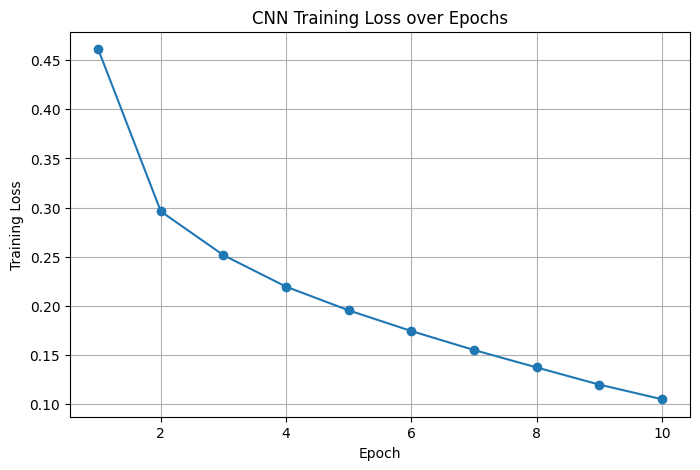

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("CNN Training Loss over Epochs")
plt.grid(True)

plt.show()

In [7]:
model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total

print(f"CNN Test Accuracy: {accuracy:.2f}%")

CNN Test Accuracy: 91.92%


In [8]:
classes = train_dataset.classes

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=classes
    )
)

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.88      0.87      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.83      0.91      0.87      1000
       Dress       0.90      0.94      0.92      1000
        Coat       0.89      0.82      0.85      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.80      0.75      0.78      1000
     Sneaker       0.95      0.98      0.97      1000
         Bag       0.99      0.98      0.99      1000
  Ankle boot       0.98      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



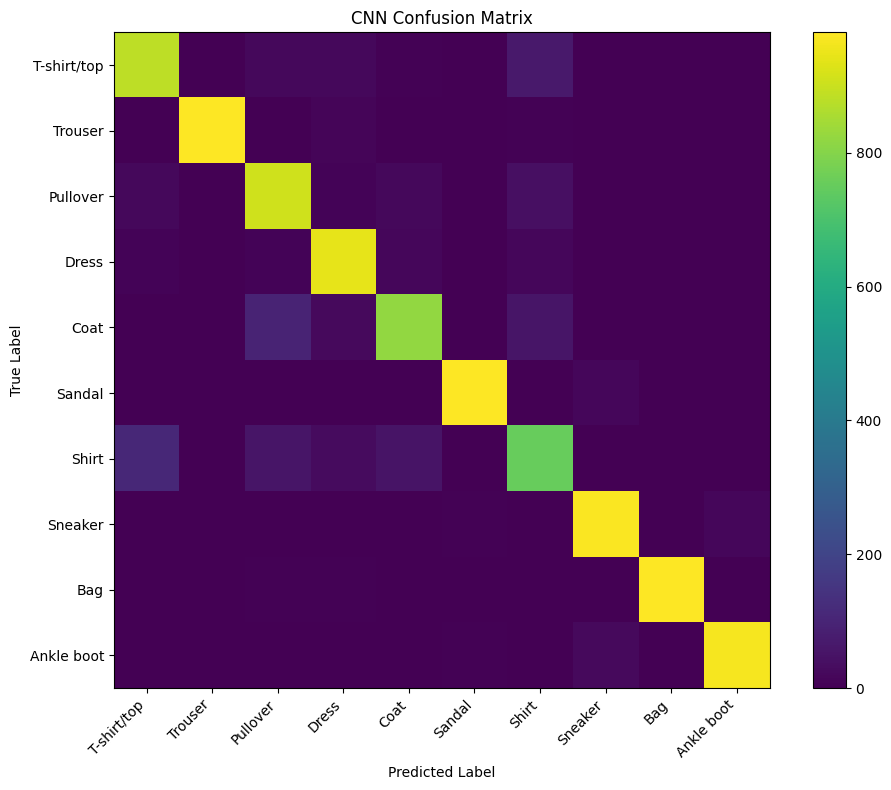

In [9]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

plt.xticks(
    range(len(classes)),
    classes,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(classes)),
    classes
)

plt.tight_layout()
plt.show()

In [10]:
torch.save(
    model.state_dict(),
    "fashion_mnist_cnn.pth"
)

print("CNN model saved successfully.")

CNN model saved successfully.


Hyperparameter Experiments

Exp 1:lr = 0.0005

In [12]:
model_exp1 = CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_exp1.parameters(),
    lr=0.0005
)

num_epochs = 10

train_losses_exp1 = []

for epoch in range(num_epochs):

    model_exp1.train()
    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_exp1(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses_exp1.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/10], Loss: 0.5234
Epoch [2/10], Loss: 0.3370
Epoch [3/10], Loss: 0.2943
Epoch [4/10], Loss: 0.2629
Epoch [5/10], Loss: 0.2418
Epoch [6/10], Loss: 0.2213
Epoch [7/10], Loss: 0.2071
Epoch [8/10], Loss: 0.1911
Epoch [9/10], Loss: 0.1771
Epoch [10/10], Loss: 0.1630


In [13]:
model_exp1.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_exp1(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy_exp1 = 100 * correct / total

print(f"Experiment 1 Accuracy: {accuracy_exp1:.2f}%")

Experiment 1 Accuracy: 91.69%


Exp 2:lr = 0.002

In [14]:
model_exp2 = CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_exp2.parameters(),
    lr=0.002
)

num_epochs = 10

train_losses_exp2 = []

for epoch in range(num_epochs):

    model_exp2.train()
    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_exp2(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses_exp2.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/10], Loss: 0.4212
Epoch [2/10], Loss: 0.2664
Epoch [3/10], Loss: 0.2238
Epoch [4/10], Loss: 0.1948
Epoch [5/10], Loss: 0.1688
Epoch [6/10], Loss: 0.1456
Epoch [7/10], Loss: 0.1266
Epoch [8/10], Loss: 0.1090
Epoch [9/10], Loss: 0.0948
Epoch [10/10], Loss: 0.0823


In [15]:
model_exp2.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_exp2(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy_exp2 = 100 * correct / total

print(f"Experiment 2 Accuracy: {accuracy_exp2:.2f}%")

Experiment 2 Accuracy: 91.78%


In [16]:
train_loader_exp3 = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

model_exp3 = CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_exp3.parameters(),
    lr=0.001
)

num_epochs = 10

train_losses_exp3 = []

for epoch in range(num_epochs):

    model_exp3.train()
    running_loss = 0.0

    for images, labels in train_loader_exp3:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_exp3(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader_exp3)
    train_losses_exp3.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/10], Loss: 0.5147
Epoch [2/10], Loss: 0.3243
Epoch [3/10], Loss: 0.2859
Epoch [4/10], Loss: 0.2529
Epoch [5/10], Loss: 0.2324
Epoch [6/10], Loss: 0.2112
Epoch [7/10], Loss: 0.1948
Epoch [8/10], Loss: 0.1786
Epoch [9/10], Loss: 0.1673
Epoch [10/10], Loss: 0.1550


In [17]:
model_exp3.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_exp3(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy_exp3 = 100 * correct / total

print(f"Experiment 3 Accuracy: {accuracy_exp3:.2f}%")

Experiment 3 Accuracy: 91.36%
